## Step 1 — Dataset Loading & Initial Understanding


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

In [2]:
df = pd.read_csv("goemotions_mrm8488_train.csv")


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 211225
Number of columns: 37


In [4]:
df.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


In [5]:
df.tail()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
211220,Everyone likes [NAME].,ee6pagw,Senshado,heroesofthestorm,t3_agjf24,t3_agjf24,1.547634e+09,16,False,0,...,1,0,0,0,0,0,0,0,0,0
211221,Well when you’ve imported about a gazillion of...,ef28nod,5inchloser,nottheonion,t3_ak26t3,t3_ak26t3,1.548553e+09,15,False,0,...,0,0,0,0,0,0,0,0,0,0
211222,That looks amazing,ee8hse1,springt1me,shittyfoodporn,t3_agrnqb,t3_agrnqb,1.547684e+09,70,False,1,...,0,0,0,0,0,0,0,0,0,0
211223,The FDA has plenty to criticize. But like here...,edrhoxh,enamedata,medicine,t3_aejqzd,t1_edrgdtx,1.547169e+09,4,False,0,...,0,0,0,0,0,0,0,0,0,0
211224,Desktop link: ^^/r/HelperBot_ ^^Downvote ^^to ...,edze9g4,HelperBot_,MorbidReality,t3_afhw30,t1_edze91s,1.547397e+09,61,True,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.sample(3, random_state=42)

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
65844,Literally everywhere. There's nothing especial...,eeochpb,KyleG,texas,t3_aiibrx,t1_eeo49lo,1.548139e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,0
54522,"[NAME] and [NAME] may be stronger, but [NAME] ...",eewnhep,King_Jorza,freefolk,t3_ajihmn,t3_ajihmn,1.548397e+09,16,False,0,...,0,0,0,0,0,0,0,0,0,1
48835,Ik I’m crying rn,ee4utnt,lloydness21,Paladins,t3_agaxxw,t1_ee4tpmc,1.547575e+09,76,False,0,...,0,0,0,0,0,0,0,1,0,0


## Step-2 Understanding the Dataset Structure

In [7]:
df.columns

Index(['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id',
       'created_utc', 'rater_id', 'example_very_unclear', 'admiration',
       'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion',
       'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust',
       'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy',
       'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief',
       'remorse', 'sadness', 'surprise', 'neutral'],
      dtype='str')

In [8]:
emotion_cols = [
    'admiration',
    'amusement',
    'anger',
    'annoyance',
    'approval',
    'caring',
    'confusion',
    'curiosity',
    'desire',
    'disappointment',
    'disapproval',
    'disgust',
    'embarrassment',
    'excitement',
    'fear',
    'gratitude',
    'grief',
    'joy',
    'love',
    'nervousness',
    'optimism',
    'pride',
    'realization',
    'relief',
    'remorse',
    'sadness',
    'surprise',
    'neutral'
]
# All Emotions
print("Number of emotion labels:", len(emotion_cols))

Number of emotion labels: 28


In [9]:
print("DataTypes :" ,df.dtypes)

print(df.info())

DataTypes : text                        str
id                          str
author                      str
subreddit                   str
link_id                     str
parent_id                   str
created_utc             float64
rater_id                  int64
example_very_unclear       bool
admiration                int64
amusement                 int64
anger                     int64
annoyance                 int64
approval                  int64
caring                    int64
confusion                 int64
curiosity                 int64
desire                    int64
disappointment            int64
disapproval               int64
disgust                   int64
embarrassment             int64
excitement                int64
fear                      int64
gratitude                 int64
grief                     int64
joy                       int64
love                      int64
nervousness               int64
optimism                  int64
pride                     in

In [10]:
df.describe(include='all')

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
count,211225,211225,211225,211225,211225,211225,2.112250e+05,211225.000000,211225,211225.000000,...,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000
unique,57732,58011,49178,483,44897,54924,NaN,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Thank you.,eew5j0j,[deleted],cringe,t3_ae6ejj,t3_ae6ejj,NaN,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,45,5,3882,895,92,64,NaN,NaN,207814,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,1.547659e+09,37.619742,NaN,0.081103,...,0.038779,0.008569,0.041259,0.006164,0.041591,0.006102,0.011954,0.031994,0.026105,0.261797
std,NaN,NaN,NaN,NaN,NaN,NaN,7.696842e+05,23.070528,NaN,0.272994,...,0.193067,0.092172,0.198890,0.078269,0.199653,0.077880,0.108679,0.175985,0.159448,0.439614
min,NaN,NaN,NaN,NaN,NaN,NaN,1.546301e+09,0.000000,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,1.546993e+09,19.000000,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,1.547664e+09,37.000000,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,1.548320e+09,57.000000,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000


## Step 3 — Data Quality Analysis

In [11]:
# missing values if any

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [12]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': missing_percentage
})

missing_summary

,Missing Values,Missing Percentage
text,0,0.0
id,0,0.0
author,0,0.0
subreddit,0,0.0
link_id,0,0.0
parent_id,0,0.0
created_utc,0,0.0
rater_id,0,0.0
example_very_unclear,0,0.0
admiration,0,0.0


In [13]:
# Duplicate values if any

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

print("Duplicate IDs:", df['id'].duplicated().sum())

print("Duplicate texts:", df['text'].duplicated().sum())

Number of duplicate rows: 0
Duplicate IDs: 153214
Duplicate texts: 153493


In [14]:
# Empty strings

empty_text = (df['text'].str.strip() == '').sum()

print("Empty text records:", empty_text)

Empty text records: 0


In [15]:
# unclear examples : 

print(df['example_very_unclear'].value_counts())
print("\n")
print(df['example_very_unclear'].value_counts(normalize=True) * 100)

example_very_unclear
False    207814
True       3411
Name: count, dtype: int64


example_very_unclear
False    98.385134
True      1.614866
Name: proportion, dtype: float64


In [16]:
print("Unique texts:", df['text'].nunique())

print("Texts appearing more than once:", 
      (df['text'].value_counts() > 1).sum())

Unique texts: 57732
Texts appearing more than once: 57663


## Step 4 — Identify the Emotion Labels

#### 4.1 Emotion frequency/distribution 

In [17]:
missing_emotion_cols = [col for col in emotion_cols if col not in df.columns]

print("Missing emotion columns:", missing_emotion_cols)

Missing emotion columns: []


In [18]:
df[emotion_cols].head()

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [19]:
# to check for binary

df[emotion_cols].apply(pd.Series.unique)

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,1,1


In [20]:
# Emotions table in detailed

emotion_counts = df[emotion_cols].sum().sort_values(ascending=False)

emotion_counts

emotion_summary = pd.DataFrame({
    'Emotion': emotion_counts.index,
    'Count': emotion_counts.values
})

emotion_summary

emotion_summary['Percentage'] = (
    emotion_summary['Count'] / len(df) * 100
).round(2)

emotion_summary

,Emotion,Count,Percentage
0,neutral,55298,26.18
1,approval,17620,8.34
2,admiration,17131,8.11
3,annoyance,13618,6.45
4,gratitude,11625,5.50
5,disapproval,11424,5.41
6,curiosity,9692,4.59
7,amusement,9245,4.38
8,realization,8785,4.16
9,optimism,8715,4.13


In [21]:
print("Most Common Emotion : " ,emotion_summary.iloc[0])
print("\n")
print("Least Common Emotion :",emotion_summary.iloc[-1])

Most Common Emotion :  Emotion       neutral
Count           55298
Percentage      26.18
Name: 0, dtype: object


Least Common Emotion : Emotion       grief
Count           673
Percentage     0.32
Name: 27, dtype: object


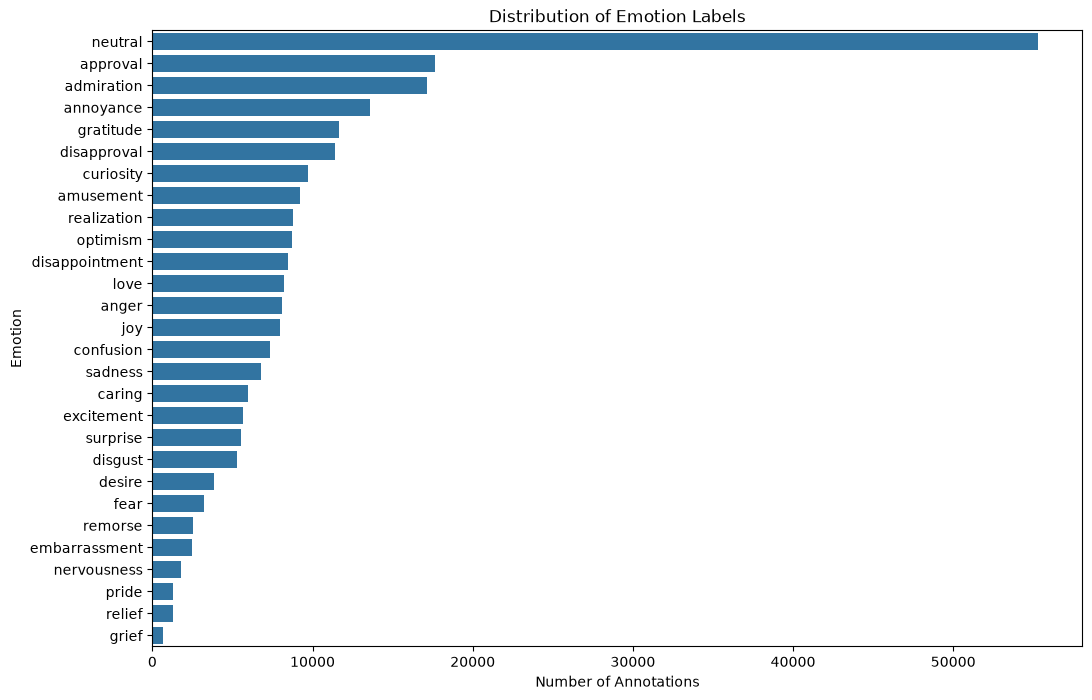

In [22]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=emotion_summary,
    x='Count',
    y='Emotion'
)

plt.title('Distribution of Emotion Labels')
plt.xlabel('Number of Annotations')
plt.ylabel('Emotion')

plt.show()

#### 4.2 Multi-Label Distribution

In [23]:
label_counts_per_row = df[emotion_cols].sum(axis=1)

label_counts_per_row.value_counts().sort_index()

0       3411
1     171820
2      31187
3       4218
4        399
5        106
6         53
7         20
8          6
9          3
10         1
12         1
Name: count, dtype: int64

In [24]:
label_counts_per_row.describe()

count    211225.000000
mean          1.181342
std           0.498757
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          12.000000
dtype: float64

In [25]:
# for multiple emotions

multiple_label_count = (label_counts_per_row > 1).sum()

multiple_label_percentage = (multiple_label_count / len(df)) * 100

print("Annotations with multiple emotion labels:", multiple_label_count)
print("Percentage with multiple emotion labels:", round(multiple_label_percentage, 2), "%")

Annotations with multiple emotion labels: 35994
Percentage with multiple emotion labels: 17.04 %


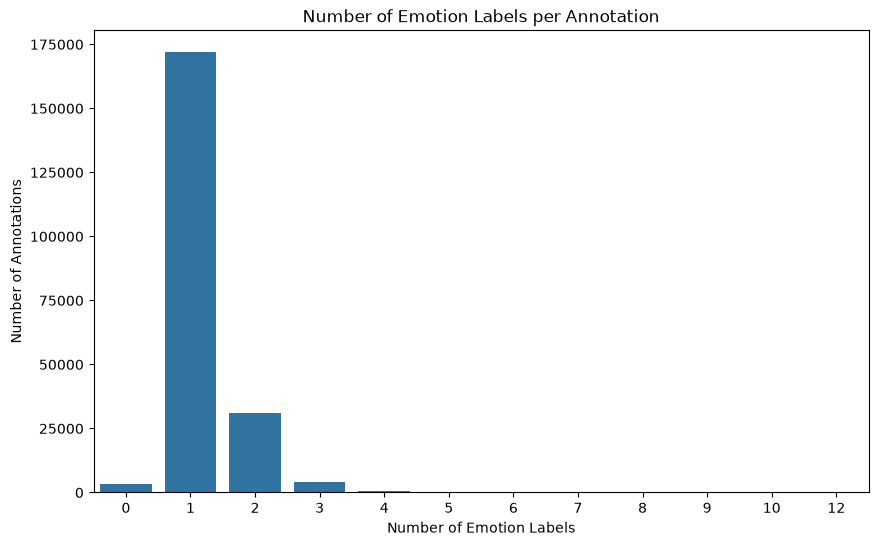

In [26]:
plt.figure(figsize=(10, 6))

sns.countplot(x=label_counts_per_row)

plt.title('Number of Emotion Labels per Annotation')
plt.xlabel('Number of Emotion Labels')
plt.ylabel('Number of Annotations')

plt.show()

In [27]:
# Rows with no emotion label

no_label_count = (label_counts_per_row == 0).sum()

print("Annotations with no emotion label:", no_label_count)
print("Percentage with no emotion label:", round((no_label_count / len(df)) * 100, 2), "%")

Annotations with no emotion label: 3411
Percentage with no emotion label: 1.61 %


In [28]:
# Rows with only one emotionn label

single_label_count = (label_counts_per_row == 1).sum()

print("Annotations with exactly one emotion:", single_label_count)
print("Percentage with exactly one emotion:", round((single_label_count / len(df)) * 100, 2), "%")

Annotations with exactly one emotion: 171820
Percentage with exactly one emotion: 81.34 %


In [29]:
unclear_and_no_label = (
    df['example_very_unclear'] &
    (label_counts_per_row == 0)
).sum()

print("Unclear examples with no emotion label:", unclear_and_no_label)

unclear_with_label = (
    df['example_very_unclear'] &
    (label_counts_per_row > 0)
).sum()

print("Unclear examples with at least one emotion label:", unclear_with_label)

Unclear examples with no emotion label: 3411
Unclear examples with at least one emotion label: 0


In [30]:
df.loc[
    label_counts_per_row == label_counts_per_row.max(),
    ['text'] + emotion_cols
]

print("Maximum number of labels:", label_counts_per_row.max())

Maximum number of labels: 12


#### 4.3 Class Imbalance Analysis

In [31]:
most_common_count = emotion_counts.max()
least_common_count = emotion_counts.min()

imbalance_ratio = most_common_count / least_common_count

print("Most common emotion count:", most_common_count)
print("Least common emotion count:", least_common_count)
print("Imbalance ratio:", round(imbalance_ratio, 2))

Most common emotion count: 55298
Least common emotion count: 673
Imbalance ratio: 82.17


In [32]:
print("Top 5 most frequent emotions:")
print(emotion_summary.head(5))

print("\nBottom 5 least frequent emotions:")
print(emotion_summary.tail(5))

Top 5 most frequent emotions:
      Emotion  Count  Percentage
0     neutral  55298       26.18
1    approval  17620        8.34
2  admiration  17131        8.11
3   annoyance  13618        6.45
4   gratitude  11625        5.50

Bottom 5 least frequent emotions:
          Emotion  Count  Percentage
23  embarrassment   2476        1.17
24    nervousness   1810        0.86
25          pride   1302        0.62
26         relief   1289        0.61
27          grief    673        0.32


In [33]:
highest_percentage = emotion_summary['Percentage'].max()
lowest_percentage = emotion_summary['Percentage'].min()

print("Highest emotion percentage:", highest_percentage, "%")
print("Lowest emotion percentage:", lowest_percentage, "%")

Highest emotion percentage: 26.18 %
Lowest emotion percentage: 0.32 %


#### 4.4 Emotion Co-occurrence Analysis

In [34]:
co_occurrence = df[emotion_cols].T.dot(df[emotion_cols])

co_occurrence

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
admiration,17131,383,63,158,1366,249,162,322,222,178,...,721,45,603,236,384,50,47,127,226,0
amusement,383,9245,65,155,418,56,138,219,59,91,...,237,15,230,18,239,23,33,90,117,0
anger,63,65,8084,1391,107,50,81,104,33,279,...,86,27,60,4,113,9,34,134,49,0
annoyance,158,155,1391,13618,247,98,171,272,62,754,...,87,50,168,17,255,21,57,186,92,0
approval,1366,418,107,247,17620,442,192,334,192,206,...,325,31,748,71,829,81,73,148,148,0
caring,249,56,50,98,442,5999,37,108,116,59,...,285,21,404,33,176,42,54,166,32,0
confusion,162,138,81,171,192,37,7359,754,32,100,...,59,34,83,8,205,8,46,59,140,0
curiosity,322,219,104,272,334,108,754,9692,175,135,...,115,42,207,29,408,12,61,143,323,0
desire,222,59,33,62,192,116,32,175,3817,85,...,167,14,356,24,92,11,17,65,22,0
disappointment,178,91,279,754,206,59,100,135,85,8469,...,84,114,138,15,296,9,104,907,85,0


In [35]:
from itertools import combinations

pair_counts = []

for emotion1, emotion2 in combinations(emotion_cols, 2):
    count = co_occurrence.loc[emotion1, emotion2]
    pair_counts.append((emotion1, emotion2, count))

pair_counts = pd.DataFrame(
    pair_counts,
    columns=['Emotion 1', 'Emotion 2', 'Co-occurrence']
)

pair_counts = pair_counts.sort_values(
    'Co-occurrence',
    ascending=False
)

pair_counts.head(20)

,Emotion 1,Emotion 2,Co-occurrence
53,anger,annoyance,1391
3,admiration,approval,1366
14,admiration,gratitude,1165
84,annoyance,disapproval,1039
222,disappointment,sadness,907
276,excitement,joy,869
119,approval,realization,829
147,confusion,curiosity,754
83,annoyance,disappointment,754
117,approval,optimism,748


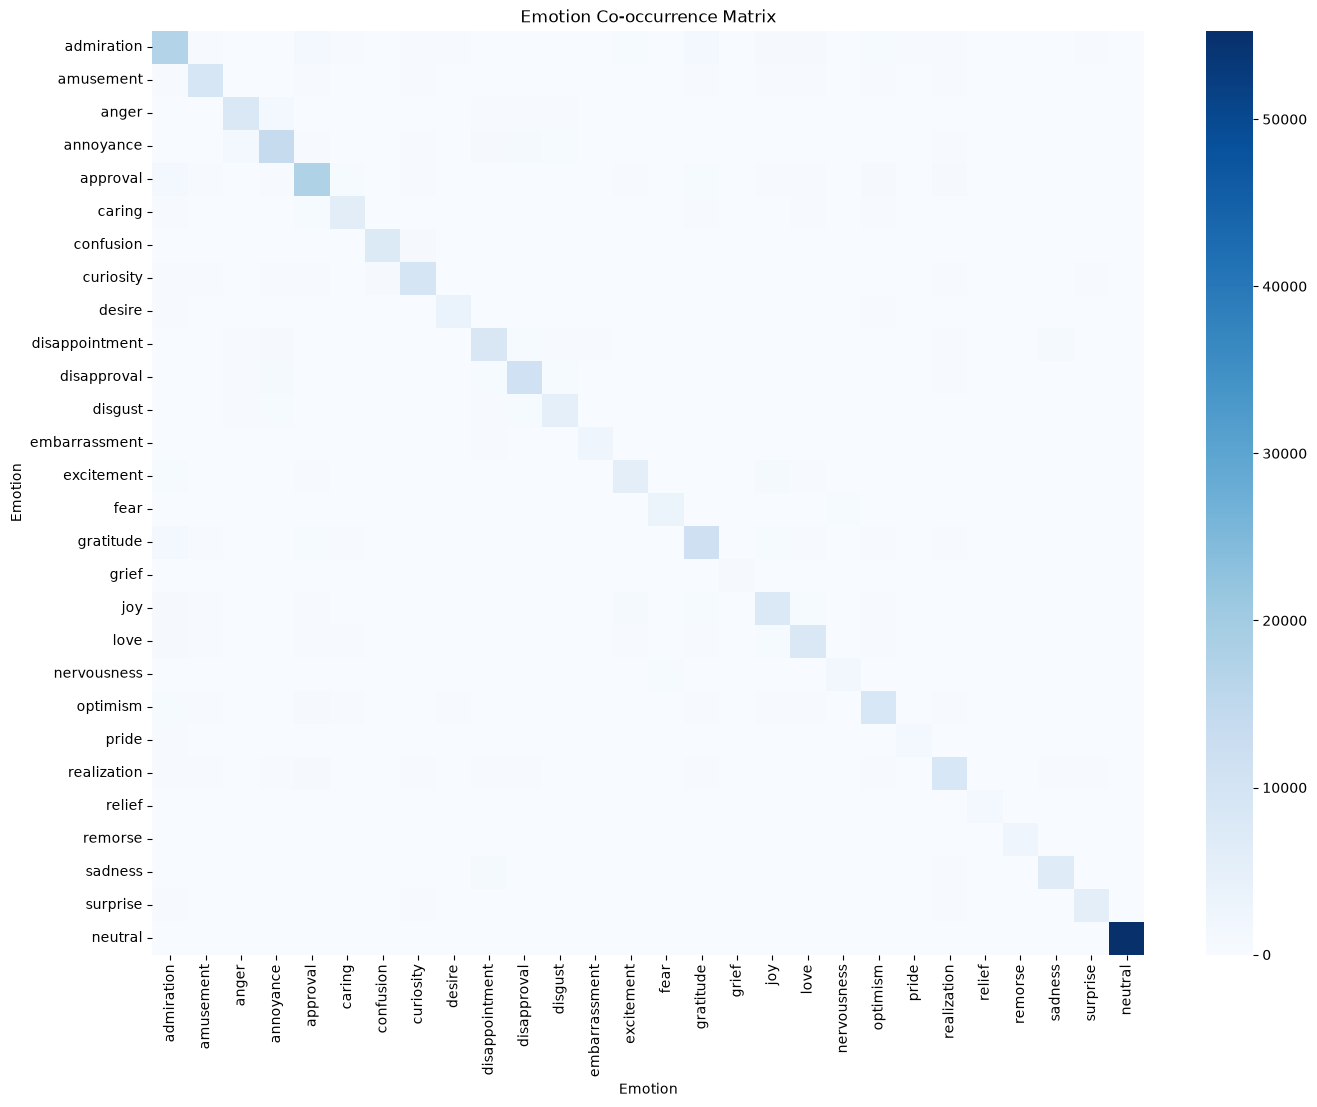

In [36]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    co_occurrence,
    cmap='Blues'
)

plt.title('Emotion Co-occurrence Matrix')
plt.xlabel('Emotion')
plt.ylabel('Emotion')

plt.show()

In [37]:
# top 10 pairs
pair_counts.head(10)

,Emotion 1,Emotion 2,Co-occurrence
53,anger,annoyance,1391
3,admiration,approval,1366
14,admiration,gratitude,1165
84,annoyance,disapproval,1039
222,disappointment,sadness,907
276,excitement,joy,869
119,approval,realization,829
147,confusion,curiosity,754
83,annoyance,disappointment,754
117,approval,optimism,748


#### Step 4.5 — conclusion for this phase


In the dataset, there are 28 emotions with varying degrees of representation among them. The emotion label `neutral` occurs most frequently (55,298 times, or 26.18%), while the least frequent label is `grief` with 673 occurrences (0.32%). There is an imbalance in the distribution of emotion labels in terms of the number of annotations: the ratio of most and least frequent emotion counts is approximately 82.17:1.

Also, it was established that the dataset includes annotations with one label as well as annotations with several labels. Single-label annotations are 171,820 (81.34%), while multiple-label annotations make up 35,994 (17.04%). Also, 3,411 (1.61%) annotations have no emotion label. All annotations without a label are annotated by the `example_very_unclear` tag, which suggests a clear relation between unclear examples and the lack of emotion labels.

The dataset has multiple records of the same text. While 153,214 duplicate IDs have been found, they are not always duplicate observations since the same text can have annotations from different annotators. There are 58,011 unique IDs and 57,732 unique text values, and most of the texts are annotated several times. So, duplicate records should not be deleted in EDA.

In conclusion, the emotion analysis of the GoEmotions dataset showed that it has highly imbalanced emotion labels distribution, substantial multi-label part, and multiple human annotations per text.

## Step-5 Text Analysis

###### In this section, the features of the text dataset such as the text length, number of words and frequency of texts size are analyzed.


In [39]:
text_length = df['text'].str.len()

text_length.head()

0     15
1    127
2     46
3     18
4     52
Name: text, dtype: int64

In [41]:
word_count = df['text'].str.split().str.len()

word_count.head()

0     3
1    21
2    10
3     4
4    10
Name: text, dtype: int64

In [48]:
text_length.describe()

count    211225.000000
mean         69.299572
std          36.536746
min           2.000000
25%          39.000000
50%          67.000000
75%          97.000000
max         703.000000
Name: text, dtype: float64

In [50]:
print(word_count.describe())

count    211225.000000
mean         12.997188
std           6.676105
min           1.000000
25%           7.000000
50%          13.000000
75%          18.000000
max          33.000000
Name: text, dtype: float64


In [52]:
text_statistics = pd.DataFrame({
    'Metric': [
        'Mean',
        'Median',
        'Minimum',
        'Maximum',
        'Standard Deviation'
    ],
    'Character Length': [
        text_length.mean(),
        text_length.median(),
        text_length.min(),
        text_length.max(),
        text_length.std()
    ],
    'Word Count': [
        word_count.mean(),
        word_count.median(),
        word_count.min(),
        word_count.max(),
        word_count.std()
    ]
})

text_statistics.round(2)

# statistics table

,Metric,Character Length,Word Count
0,Mean,69.30,13.00
1,Median,67.00,13.00
2,Minimum,2.00,1.00
3,Maximum,703.00,33.00
4,Standard Deviation,36.54,6.68


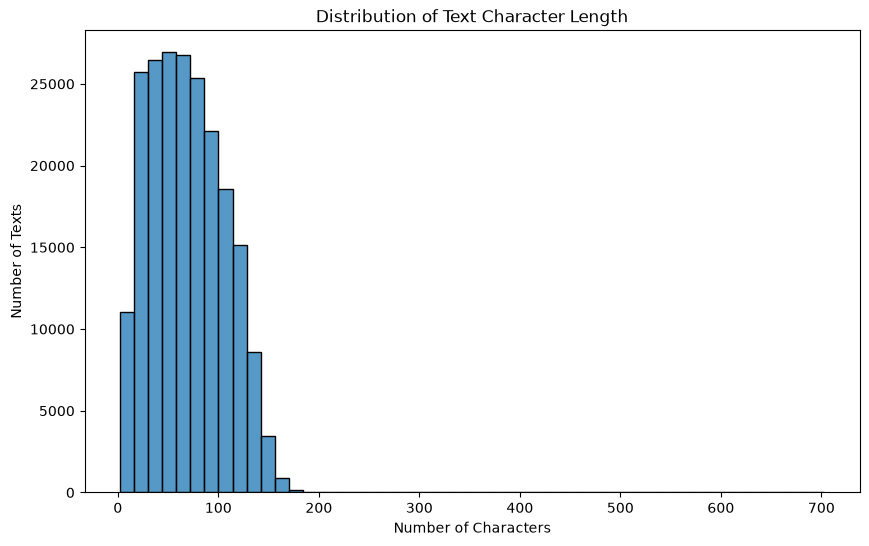

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(text_length, bins=50)

plt.title('Distribution of Text Character Length')
plt.xlabel('Number of Characters')
plt.ylabel('Number of Texts')

plt.show()

# graph for which texts are short, medium-length, or long.

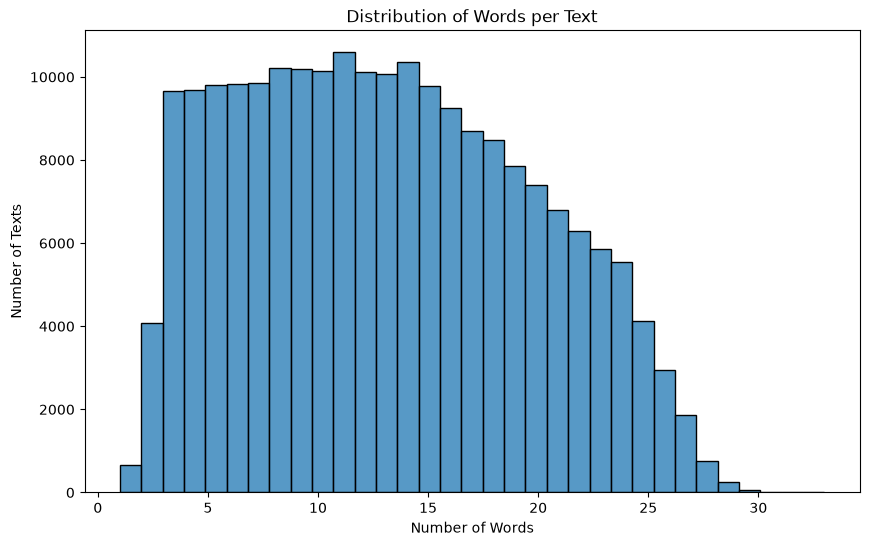

In [56]:
plt.figure(figsize=(10, 6))

sns.histplot(word_count, bins=33)

plt.title('Distribution of Words per Text')
plt.xlabel('Number of Words')
plt.ylabel('Number of Texts')

plt.show()

# Distribution of words per text

In [58]:
shortest_texts = df.loc[
    text_length.nsmallest(10).index,
    ['text']
]

shortest_texts

,text
111828,ok
118619,XD
131731,ok
151432,XD
158737,ok
188631,XD
6664,:^)
11228,Yes
11806,art
16910,(:)


In [61]:
longest_texts = df.loc[
    text_length.nlargest(10).index,
    ['text']
]

longest_texts

,text
28840,This person is the smartest person to play tow...
103896,This person is the smartest person to play tow...
172005,This person is the smartest person to play tow...
54167,For your kindness to mobile users I give a pla...
59642,For your kindness to mobile users I give a pla...
180267,For your kindness to mobile users I give a pla...
20825,here you go: |Games|Home|Away|Team|vs W-L 18-1...
47616,here you go: |Games|Home|Away|Team|vs W-L 18-1...
167928,here you go: |Games|Home|Away|Team|vs W-L 18-1...
6591,No the whippet sound is WUBWUBWUBWUBWUBWUBWUBW...


## Step 6 — EDA Findings and Conclusion

### 6.1 General EDA Results

### Dataset structure

GoEmotions dataset consists of 211,225 annotation records that include 37 columns: text information, metadata, and 28 emotion-label columns.

### Data quality

No missing values have been detected throughout the dataset; there are no fully duplicated rows. No empty text records have been found.

The dataset has repeated IDs as one text could be annotated by several raters at once. There are 58,011 unique IDs compared to 211,225 annotation records. This implies that repeated IDs should not be considered ordinary duplicates and should not be simply deleted due to the annotation structure specifics.

A total of 3,411 records (1.61%) are described as very unclear. These records have no emotion labels.

### Emotion distribution

There is a significant label imbalance in terms of emotions. Most frequently assigned emotion is neutral with 55,298 annotations (26.18%), the least frequent one is grief – 673 annotations (0.32%). Ratio between counts of the most and least frequent emotion labels is about 82.17:1.

### Label structure

Majority of the records (81.34%, 171,820 records) have exactly one emotion label. In 17.04% (35,994 records) of all records there are multiple emotion labels. The largest amount of emotion labels assigned to one annotation is 12.

It shows that the annotation data is characterized by a multi-label component.

### Text characteristics

On average, the text has 69 characters and 13 words. Corresponding median values are 67 characters and 13 words as well. The texts vary in length from 2 to 703 characters and from 1 to 33 words.

These distributions indicate that most texts are quite short, which is important taking into account such parameters as tokenization and maximum sequence length in case of Transformer-based modeling.

### Implications for machine learning

The discovered emotion-label imbalance should be taken into account during training and evaluation of classification models. While evaluation, one should not use accuracy as a measure as performance on minority classes can be hidden behind the majority class.

The fact that there are several annotations for one text and the multi-label data should be considered when generating the final training labels.

Shortness of the texts indicates that the dataset is generally suitable for Transformer-based text classification tasks, however, the correct tokenization and sequence-length strategy should be established during preprocessing.

### 6.2 Conclusion

EDA reveals that GoEmotions dataset is huge, consists of high-quality text entries without any missing data and includes 28 emotion labels. However, this dataset is quite unbalanced in terms of emotion labels and includes single-label and multi-label annotations.

The presence of repeated IDs reveals that there are several human annotations for each text and, therefore, repeated IDs can’t be eliminated as redundant observations. In addition to this, the unclear examples and their absence of emotion labels should be taken into account during preprocessing.

These results of EDA serve as the basis for further decisions related to preprocessing, label creation, model training, and testing.